# Quick implementation for trying to detect process change points based on complexity curves

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Get the project root
# The notebook is in: scripts/change_study/notebooks/
# So we need to go up 3 levels to reach the project root
current_dir = Path.cwd()
# Navigate up to project root based on where we are
if "notebooks" in str(current_dir):
    # We're in the notebooks directory, go up 3 levels
    project_root = current_dir.parent.parent.parent
elif "change_study" in str(current_dir):
    # We're in change_study, go up 2 levels
    project_root = current_dir.parent.parent
elif "scripts" in str(current_dir):
    # We're in scripts, go up 1 level
    project_root = current_dir.parent
else:
    # Assume we're already at project root
    project_root = current_dir

# Load the CSV file
csv_path = project_root / "results" / "change_study" / "complexity_assessment" / "KA25_001_00_S" / "processGraphsPDefaultWDefault__fixed_w200_o20" / "complexity.csv"
df = pd.read_csv(csv_path)

# remove overlapping windows by filtering out all rows where first_index is not divisible by 200
df = df[df['first_index'] % 200 == 0]

# Calculate window mid-point: first_index + (last_index - first_index) / 2
# This simplifies to: (first_index + last_index) / 2
df['window_midpoint'] = (df['first_index'] + df['last_index']) / 2

# Select only columns that start with "measure_"
measure_columns = [col for col in df.columns if col.startswith('measure_')]
df_measures = df[['window_midpoint'] + measure_columns].copy()

# Set window_midpoint as index
df_measures.set_index('window_midpoint', inplace=True)

# Remove "measure_" prefix from column names
df_measures.columns = df_measures.columns.str.replace('measure_', '', regex=False)

# Display the result
print(f"DataFrame shape: {df_measures.shape}")
print(f"\nColumns: {list(df_measures.columns)}")
print(f"\nFirst few rows:")
df_measures.head()

DataFrame shape: (15, 21)

Columns: ['Number of Distinct Activities', 'Number of Distinct Directly-Follows Relations', 'Number of Distinct Traces', 'Average Affinity', 'Average Edit Distance', 'Deviation from Random', 'Min. Trace Length', 'Avg. Trace Length', 'Max. Trace Length', 'Number of Events', 'Number of Traces', 'Average Distinct Activities per Trace', 'Estimated Number of Acyclic Paths', 'Lempel-Ziv Complexity', 'Number of Ties in Paths to Goal', 'Percentage of Distinct Traces', 'Structure', 'Variant Entropy', 'Normalized Variant Entropy', 'Sequence Entropy', 'Normalized Sequence Entropy']

First few rows:


,Number of Distinct Activities,Number of Distinct Directly-Follows Relations,Number of Distinct Traces,Average Affinity,Average Edit Distance,Deviation from Random,Min. Trace Length,Avg. Trace Length,Max. Trace Length,Number of Events,...,Average Distinct Activities per Trace,Estimated Number of Acyclic Paths,Lempel-Ziv Complexity,Number of Ties in Paths to Goal,Percentage of Distinct Traces,Structure,Variant Entropy,Normalized Variant Entropy,Sequence Entropy,Normalized Sequence Entropy
window_midpoint,,,,,,,,,,,,,,,,,,,,,
99.5,12.0,28.0,69.0,0.402767,9.825327,0.740849,2.0,8.650,39.0,1730.0,...,5.000,22.908677,566.0,981.0,0.345,0.805556,2023.084527,0.631965,5663.193412,0.439053
299.5,12.0,31.0,70.0,0.404636,9.522513,0.739502,2.0,8.600,40.0,1720.0,...,5.120,39.810717,572.0,955.0,0.350,0.784722,2066.835477,0.629937,5722.625076,0.446587
499.5,12.0,31.0,69.0,0.405810,10.251709,0.736089,2.0,9.025,38.0,1805.0,...,5.095,39.810717,579.0,1011.0,0.345,0.784722,2213.953911,0.623478,6139.665280,0.453632
699.5,12.0,29.0,76.0,0.404987,11.066281,0.734709,2.0,9.750,51.0,1950.0,...,5.140,27.542287,610.0,1169.0,0.380,0.798611,2547.011324,0.618144,6674.539773,0.451825
899.5,12.0,31.0,70.0,0.406420,10.599598,0.730688,2.0,9.170,52.0,1834.0,...,5.070,39.810717,600.0,1059.0,0.350,0.784722,2259.110640,0.609699,5966.827168,0.432970


Normalized dataframe created
Normalized values range: [0.000, 1.000]


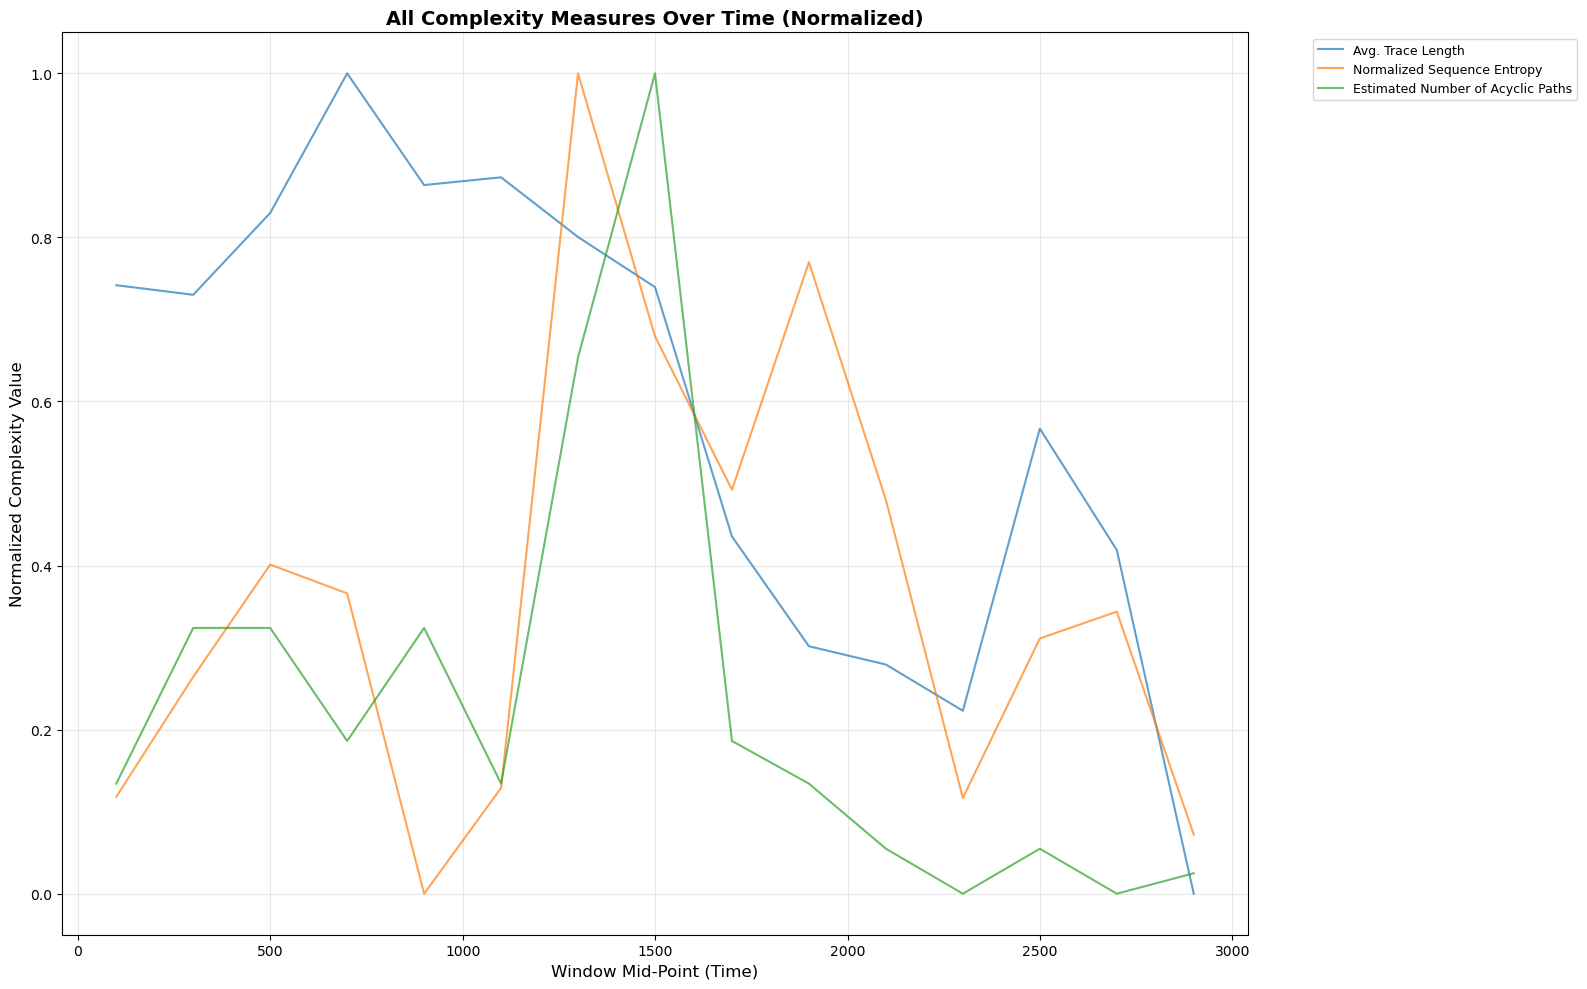

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Normalize the dataframe by column (min-max normalization: (x - min) / (max - min))
# This scales each column to [0, 1] range
df_measures_normalized = df_measures.copy()

# select only some columns
df_measures_normalized = df_measures_normalized[
    ['Avg. Trace Length', 'Normalized Sequence Entropy', 'Estimated Number of Acyclic Paths']
]
for col in df_measures_normalized.columns:
    col_min = df_measures_normalized[col].min()
    col_max = df_measures_normalized[col].max()
    if col_max != col_min:  # Avoid division by zero
        df_measures_normalized[col] = (df_measures_normalized[col] - col_min) / (col_max - col_min)
    else:
        df_measures_normalized[col] = 0  # If all values are the same, set to 0

print("Normalized dataframe created")
print(f"Normalized values range: [{df_measures_normalized.min().min():.3f}, {df_measures_normalized.max().max():.3f}]")

# Plot all complexity measures over time
plt.figure(figsize=(16, 10))
for col in df_measures_normalized.columns:
    plt.plot(df_measures_normalized.index, df_measures_normalized[col], label=col, alpha=0.7, linewidth=1.5)

plt.xlabel('Window Mid-Point (Time)', fontsize=12)
plt.ylabel('Normalized Complexity Value', fontsize=12)
plt.title('All Complexity Measures Over Time (Normalized)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt
import ipywidgets as widgets
from ipywidgets import interact
import sys
from pathlib import Path
from pm4py.objects.log.importer.xes import importer as xes_importer

# Add project root to path
sys.path.insert(0, str(Path().resolve().parent.parent.parent))

from utils import helpers, constants
from plugins.cdrift_evaluation.cdrift.approaches.complexity_drift_detection.complexity_drift_detection import detect_change

# Load data dictionary
data_dictionary = helpers.load_data_dictionary(
    constants.get_data_dictionary_path(),
    get_real=True,
    get_synthetic=True,
)

# Get available complexity metrics
available_metrics = constants.ALL_METRIC_NAMES

# Create widgets
dataset_dropdown = widgets.Dropdown(
    options=sorted(data_dictionary.keys()),
    description="Dataset:",
    style={"description_width": "initial"},
)

metric_dropdown = widgets.Dropdown(
    options=available_metrics,
    value="Avg. Trace Length",
    description="Complexity Metric:",
    style={"description_width": "initial"},
)

window_size_slider = widgets.IntSlider(
    value=200,
    min=50,
    max=1000,
    step=50,
    description="Window Size:",
    style={"description_width": "initial"},
)

step_size_slider = widgets.IntSlider(
    value=200,
    min=10,
    max=500,
    step=10,
    description="Step Size:",
    style={"description_width": "initial"},
)

min_size_slider = widgets.IntSlider(
    value=2,
    min=2,
    max=20,
    step=1,
    description="Min Consecutive Windows:",
    style={"description_width": "initial"},
)

pen_slider = widgets.FloatSlider(
    value=3.0,
    min=0.5,
    max=1000.0,
    step=0.5,
    description="Penalty:",
    readout_format=".2f",
    style={"description_width": "initial"},
)

first_window_start_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=500,
    step=10,
    description="First Window Start:",
    style={"description_width": "initial"},
)


# Cache for loaded logs
_log_cache = {"dataset": None, "log": None}

def run_change_detection(
    dataset: str,
    complexity_metric: str,
    window_size: int,
    step_size: int,
    min_size: int,
    pen: float,
    first_window_start: int,
):
    """Load log, detect change points, and visualize results.
    
    Returns
    -------
    List[int]
        List of detected change point trace indices.
    """
    if dataset not in data_dictionary:
        print(f"Error: Dataset '{dataset}' not found in data dictionary")
        return []

    # Load log only if dataset changed
    if _log_cache["dataset"] != dataset:
        # Resolve path relative to project root
        relative_path = data_dictionary[dataset]["path"]
        log_path = constants.ROOT / relative_path
        if not log_path.exists():
            print(f"Error: Log file not found at {log_path}")
            print(f"  (resolved from relative path: {relative_path})")
            return []

        print(f"Loading log: {dataset}")
        log = xes_importer.apply(str(log_path))
        print(f"Loaded {len(log)} traces")
        
        # Update cache
        _log_cache["dataset"] = dataset
        _log_cache["log"] = log
    else:
        log = _log_cache["log"]
        print(f"Using cached log: {dataset} ({len(log)} traces)")

    # Detect change points
    print(f"Detecting change points with:")
    print(f"  - Complexity metric: {complexity_metric}")
    print(f"  - Window size: {window_size}")
    print(f"  - Step size: {step_size}")
    print(f"  - First window start: {first_window_start}")
    print(f"  - Min consecutive windows: {min_size}")
    print(f"  - Penalty: {pen}")
    
    try:
        change_points = detect_change(
            log=log,
            window_size=window_size,
            penalty=pen,
            complexity_metric=complexity_metric,
            min_consecutive_windows=min_size,
            step_size=step_size,
            first_window_start=first_window_start,
            use_cache=True,
            log_id=dataset,
        )
        print(f"Detected {len(change_points)} change point(s): {change_points}")
    except Exception as e:
        print(f"Error during change point detection: {e}")
        import traceback
        traceback.print_exc()
        return []

    # Visualize results
    # Re-run complexity assessment to get the metric values for plotting
    from utils.complexity.assessors import assess_complexity_via_fixed_sized_windows

    df = assess_complexity_via_fixed_sized_windows(
        pm4py_log=log,
        window_size=window_size,
        offset=step_size,  # Use step_size parameter
        dataset_key="temp",
        configuration_name="temp",
        approach_name="temp",
        adapter_names=["local", "vidgof_sample"],
        add_prefix=True,
        include_adapter_name=False,
    )

    # Find the metric column
    metric_column = f"measure_{complexity_metric}"
    if metric_column not in df.columns:
        # Try alternative formats
        possible_columns = [
            metric_column,
            f"measure_{complexity_metric.lower()}",
            f"measure_{complexity_metric.replace(' ', '_')}",
        ]
        metric_column = None
        for col in possible_columns:
            if col in df.columns:
                metric_column = col
                break

        if metric_column is None:
            for col in df.columns:
                if col.startswith("measure_") and complexity_metric.lower() in col.lower():
                    metric_column = col
                    break

        if metric_column is None:
            print(f"Error: Could not find metric column for '{complexity_metric}'")
            print(f"Available measure columns: {[c for c in df.columns if c.startswith('measure_')]}")
            return []

    # Extract metric values
    y = df[metric_column].dropna()
    x = df.loc[y.index, "last_index"]  # Use last_index as x-axis (trace index)

    # Convert change points (trace indices) to window indices
    # Change points are trace indices, we need to find which window each belongs to
    change_point_window_indices = []
    for cp in change_points:
        # Find the window index where the change point occurs
        # Find the first window where last_index >= cp
        mask = df.loc[y.index, "last_index"] >= cp
        if mask.any():
            window_idx = y.index[mask][0]
            # Get the position in the y array
            window_pos = list(y.index).index(window_idx)
            change_point_window_indices.append(window_pos)
    
    # Create breakpoints list (includes end of data)
    bkps = change_point_window_indices + [len(y)]

    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(x, y, "b-", linewidth=1.5, marker="o", markersize=3, label=complexity_metric)
    ax.set_xlabel("Trace Index", fontsize=12)
    ax.set_ylabel(complexity_metric, fontsize=12)
    ax.set_title(f"Change Point Detection: {dataset}\n{complexity_metric} (window_size={window_size}, step_size={step_size}, first_start={first_window_start}, penalty={pen})", fontsize=13)
    ax.grid(True, alpha=0.3)

    # Mark change points with vertical lines
    if change_points:
        for cp in change_points:
            ax.axvline(x=cp, color="r", linestyle="--", linewidth=2, alpha=0.7, label="Change Point" if cp == change_points[0] else "")
        
        # Overlay fitted line per segment
        start = 0
        for end in bkps:
            if end > start:
                seg_x = x.iloc[start:end].values
                seg_y = y.iloc[start:end].values
                if len(seg_x) >= 2:
                    # Fit y = a + b*x on this segment
                    b, a = np.polyfit(seg_x, seg_y, deg=1)  # slope b, intercept a
                    ax.plot(seg_x, a + b * seg_x, linewidth=2, alpha=0.9, color="orange", label="Trend" if start == 0 else "")
                start = end
        
        ax.legend(loc="best")
    else:
        ax.text(0.5, 0.95, "No change points detected", transform=ax.transAxes, 
                ha="center", va="top", bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.5))

    plt.tight_layout()
    plt.show()
    
    # Return change points
    return change_points


# Create interactive widget for run_change_detection
interact(
    run_change_detection,
    dataset=dataset_dropdown,
    complexity_metric=metric_dropdown,
    window_size=window_size_slider,
    step_size=step_size_slider,
    min_size=min_size_slider,
    pen=pen_slider,
    first_window_start=first_window_start_slider,
)

interactive(children=(Dropdown(description='Dataset:', options=('ACCRE', 'BPIC11', 'BPIC12', 'BPIC13_cp', 'BPI…

<function __main__.run_change_detection(dataset: str, complexity_metric: str, window_size: int, step_size: int, min_size: int, pen: float, first_window_start: int)>

In [ ]:
def run_penalty_grid(
    dataset: str,
    complexity_metric: str,
    window_size: int,
    step_size: int,
    min_size: int,
    first_window_start: int,
):
    """Run change point detection for a range of penalty values and plot results.
    
    Starts at penalty=0, increments by 10 until no change points are found.
    Creates a plot showing number of change points vs penalty value.
    """
    penalties = []
    num_change_points = []
    
    penalty = 0.0
    max_iterations = 1000  # Safety limit
    
    print(f"Running penalty grid search for {dataset}")
    print(f"  - Complexity metric: {complexity_metric}")
    print(f"  - Window size: {window_size}")
    print(f"  - Step size: {step_size}")
    print(f"  - First window start: {first_window_start}")
    print(f"  - Min consecutive windows: {min_size}")
    print()
    
    iteration = 0
    while iteration < max_iterations:
        # Call run_change_detection but suppress output for grid search
        # We'll call detect_change directly to avoid plotting each time
        if dataset not in data_dictionary:
            print(f"Error: Dataset '{dataset}' not found in data dictionary")
            break
            
        # Load log if needed (reuse cache logic)
        if _log_cache["dataset"] != dataset:
            relative_path = data_dictionary[dataset]["path"]
            log_path = constants.ROOT / relative_path
            if not log_path.exists():
                print(f"Error: Log file not found at {log_path}")
                break
            log = xes_importer.apply(str(log_path))
            _log_cache["dataset"] = dataset
            _log_cache["log"] = log
        else:
            log = _log_cache["log"]
        
        # Detect change points directly (without visualization)
        try:
            change_points = detect_change(
                log=log,
                window_size=window_size,
                penalty=penalty,
                complexity_metric=complexity_metric,
                min_consecutive_windows=min_size,
                step_size=step_size,
                first_window_start=first_window_start,
                use_cache=True,
                log_id=dataset,
            )
            
            num_cps = len(change_points)
            penalties.append(penalty)
            num_change_points.append(num_cps)
            
            # print(f"Penalty={penalty:6.1f}: {num_cps} change point(s)")
            
            # Stop if no change points found
            if num_cps == 0:
                break
                
        except Exception as e:
            print(f"Error at penalty={penalty}: {e}")
            break
        
        penalty += 10.0
        iteration += 1
    
    # Create plot - clear any existing figures first
    plt.close('all')  # Close all existing figures
    
    if len(penalties) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(penalties, num_change_points, 'o-', linewidth=2, markersize=6, color='tab:blue')
        ax.set_xlabel("Penalty", fontsize=12)
        ax.set_ylabel("Number of Change Points", fontsize=12)
        ax.set_title(f"Penalty Grid Search: {dataset}\n{complexity_metric} (window_size={window_size}, step_size={step_size}, first_start={first_window_start})", fontsize=13)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)
        
        # Add value labels on points
        for i, (p, n) in enumerate(zip(penalties, num_change_points)):
            ax.annotate(f'{n}', (p, n), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nSummary: Tested {len(penalties)} penalty values")
        print(f"  Range: {penalties[0]:.1f} to {penalties[-1]:.1f}")
        print(f"  Max change points: {max(num_change_points)} at penalty={penalties[num_change_points.index(max(num_change_points))]:.1f}")
    else:
        print("No results to plot")

# Create interactive widget for run_penalty_grid
interact(
    run_penalty_grid,
    dataset=dataset_dropdown,
    complexity_metric=metric_dropdown,
    window_size=window_size_slider,
    step_size=step_size_slider,
    min_size=min_size_slider,
    first_window_start=first_window_start_slider,
)

# Create interactive widget for run_penalty_grid
interact(
    run_penalty_grid,
    dataset=dataset_dropdown,
    complexity_metric=metric_dropdown,
    window_size=window_size_slider,
    step_size=step_size_slider,
    min_size=min_size_slider,
    first_window_start=first_window_start_slider,
)

interactive(children=(Dropdown(description='Dataset:', options=('ACCRE', 'BPIC11', 'BPIC12', 'BPIC13_cp', 'BPI…

interactive(children=(Dropdown(description='Dataset:', options=('ACCRE', 'BPIC11', 'BPIC12', 'BPIC13_cp', 'BPI…

<function __main__.run_penalty_grid(dataset: str, complexity_metric: str, window_size: int, step_size: int, min_size: int, first_window_start: int)>

In [5]:
from typing import List, Tuple
import numpy as np
import math

def aggregate_cps_by_support_pct(
    window_size: int,
    cps_per_run: List[List[int]],
    T_max: int,
    threshold_pct: float,      # e.g. 0.5 = 50% of runs
    step: int = 1,
):
    """
    Returns [(cp_center, support_pct, (plateau_start, plateau_end)), ...]
    """
    assert 0 < threshold_pct <= 1.0

    w2 = window_size / 2.0
    n_runs = len(cps_per_run)
    grid = np.arange(0, T_max, step, dtype=int)

    support = np.zeros(len(grid), dtype=int)

    for run_cps in cps_per_run:
        if not run_cps:
            continue
        run_cps = np.asarray(run_cps, dtype=float)
        dmin = np.min(np.abs(grid[:, None] - run_cps[None, :]), axis=1)
        support += (dmin <= w2).astype(int)

    support_pct = support / n_runs
    mask = support_pct >= threshold_pct

    results = []
    i = 0
    while i < len(grid):
        if not mask[i]:
            i += 1
            continue
        j = i
        while j < len(grid) and mask[j]:
            j += 1

        plateau_times = grid[i:j]
        plateau_support_pct = float(np.max(support_pct[i:j]))
        cp_center = int(round(float(np.mean(plateau_times))))

        results.append(
            (cp_center, plateau_support_pct,
             (int(plateau_times[0]), int(plateau_times[-1])))
        )
        i = j

    return results

In [7]:
def find_accurate_cps(
    dataset: str,
    complexity_metric: str,
    window_size: int,
    step_size: int,
    min_size: int,
    first_window_start: int,
    number_of_window_fractions: int,
    pen: float = 3.0,
    threshold_pct: float = 0.5,
):
    """Find accurate change points by running detection with multiple window start offsets.
    
    Divides window_size by number_of_window_fractions to get window fraction step size.
    Uses each fraction as a window start offset, computes change points for each,
    and aggregates results using aggregate_cps_by_support_pct.
    
    Parameters
    ----------
    dataset : str
        Dataset name from data dictionary.
    complexity_metric : str
        Complexity metric to use.
    window_size : int
        Window size.
    step_size : int
        Step size between windows.
    min_size : int
        Minimum consecutive windows.
    first_window_start : int
        Base first window start.
    number_of_window_fractions : int
        Number of window fractions to divide window_size by.
    pen : float, optional
        Penalty parameter for PELT. Default is 3.0.
    threshold_pct : float, optional
        Threshold percentage for aggregation (0-1). Default is 0.5 (50%).
    
    Returns
    -------
    List[Tuple[int, float, Tuple[int, int]]]
        List of (cp_center, support_pct, (plateau_start, plateau_end)) tuples.
    """
    if dataset not in data_dictionary:
        print(f"Error: Dataset '{dataset}' not found in data dictionary")
        return []
    
    # Load log if needed
    if _log_cache["dataset"] != dataset:
        relative_path = data_dictionary[dataset]["path"]
        log_path = constants.ROOT / relative_path
        if not log_path.exists():
            print(f"Error: Log file not found at {log_path}")
            return []
        log = xes_importer.apply(str(log_path))
        _log_cache["dataset"] = dataset
        _log_cache["log"] = log
    else:
        log = _log_cache["log"]
    
    # Calculate window fraction step size
    window_fraction_step = window_size / number_of_window_fractions
    
    print(f"Finding accurate change points for {dataset}")
    print(f"  - Complexity metric: {complexity_metric}")
    print(f"  - Window size: {window_size}")
    print(f"  - Step size: {step_size}")
    print(f"  - Base first window start: {first_window_start}")
    print(f"  - Number of window fractions: {number_of_window_fractions}")
    print(f"  - Window fraction step: {window_fraction_step:.1f}")
    print(f"  - Penalty: {pen}")
    print(f"  - Threshold: {threshold_pct*100:.0f}%")
    print()
    
    # Collect change points from all runs
    cps_per_run = []
    window_starts = []
    
    for i in range(number_of_window_fractions):
        # Calculate window start offset for this fraction
        window_start_offset = int(round(i * window_fraction_step))
        actual_first_window_start = first_window_start + window_start_offset
        
        print(f"Run {i+1}/{number_of_window_fractions}: first_window_start={actual_first_window_start}")
        
        try:
            change_points = detect_change(
                log=log,
                window_size=window_size,
                penalty=pen,
                complexity_metric=complexity_metric,
                min_consecutive_windows=min_size,
                step_size=step_size,
                first_window_start=actual_first_window_start,
                use_cache=True,
                log_id=dataset,
            )
            
            cps_per_run.append(change_points)
            window_starts.append(actual_first_window_start)
            print(f"  -> Found {len(change_points)} change point(s): {change_points}")
            
        except Exception as e:
            print(f"  -> Error: {e}")
            cps_per_run.append([])
            window_starts.append(actual_first_window_start)
    
    print()
    
    # Get maximum trace index (T_max)
    T_max = len(log)
    
    # Aggregate change points
    aggregated_results = aggregate_cps_by_support_pct(
        window_size=window_size,
        cps_per_run=cps_per_run,
        T_max=T_max,
        threshold_pct=threshold_pct,
        step=1,
    )
    
    print(f"Aggregated Results (threshold={threshold_pct*100:.0f}%):")
    print(f"  Found {len(aggregated_results)} aggregated change point(s)")
    for cp_center, support_pct, (plateau_start, plateau_end) in aggregated_results:
        print(f"  - CP at {cp_center} (support: {support_pct*100:.1f}%, range: {plateau_start}-{plateau_end})")
    
    # Visualize results
    if aggregated_results or any(cps_per_run):
        fig, ax = plt.subplots(figsize=(14, max(6, number_of_window_fractions * 0.8)))
        
        # Plot individual runs' change points as scatter points
        # Each run gets a different y-position
        for run_idx, (cps, ws) in enumerate(zip(cps_per_run, window_starts)):
            if cps:
                # Plot each change point as a marker at the run's y-position
                ax.scatter(cps, [run_idx] * len(cps), alpha=0.6, s=100, 
                          color='gray', marker='x', linewidths=2,
                          label=f'Run {run_idx+1} (start={ws})' if run_idx < 3 else '')
        
        # Plot aggregated change points (red vertical lines)
        for cp_center, support_pct, (plateau_start, plateau_end) in aggregated_results:
            ax.axvline(x=cp_center, color='r', linestyle='-', linewidth=3, alpha=0.8, 
                      label=f'Aggregated CP (support: {support_pct*100:.0f}%)' if cp_center == aggregated_results[0][0] else '')
            # Shade the plateau range
            ax.axvspan(plateau_start, plateau_end, alpha=0.15, color='red')
        
        ax.set_xlabel("Trace Index", fontsize=12)
        ax.set_ylabel("Run Index (Window Start)", fontsize=12)
        ax.set_title(f"Aggregated Change Points: {dataset}\n{complexity_metric} (window_size={window_size}, fractions={number_of_window_fractions}, threshold={threshold_pct*100:.0f}%)", fontsize=13)
        ax.set_ylim(-0.5, len(cps_per_run) - 0.5)
        ax.set_yticks(range(len(cps_per_run)))
        ax.set_yticklabels([f"Run {i+1}\n(start={ws})" for i, ws in enumerate(window_starts)])
        ax.grid(True, alpha=0.3, axis='x')
        if aggregated_results or any(cps_per_run):
            ax.legend(loc='upper right', fontsize=9)
        
        plt.tight_layout()
        plt.show()
    
    return aggregated_results


number_of_window_fractions_slider = widgets.IntSlider(
    value=4,
    min=1,
    max=20,
    step=1,
    description="Number of Window Fractions:",
    style={"description_width": "initial"},
)

# Create interactive widget
interact(
    find_accurate_cps,
    dataset=dataset_dropdown,
    complexity_metric=metric_dropdown,
    window_size=window_size_slider,
    step_size=step_size_slider,
    min_size=min_size_slider,
    first_window_start=first_window_start_slider,
    number_of_window_fractions=number_of_window_fractions_slider,
    pen=pen_slider,  # Add penalty slider
    threshold_pct=widgets.FloatSlider(
        value=0.5,
        min=0.1,
        max=1.0,
        step=0.1,
        description="Threshold %:",
        style={"description_width": "initial"},
    ),
)

interactive(children=(Dropdown(description='Dataset:', index=22, options=('ACCRE', 'BPIC11', 'BPIC12', 'BPIC13…

<function __main__.find_accurate_cps(dataset: str, complexity_metric: str, window_size: int, step_size: int, min_size: int, first_window_start: int, number_of_window_fractions: int, pen: float = 3.0, threshold_pct: float = 0.5)>